# HTDemucs Spatial Finetune - Single-Run Test

This notebook **evaluates one** *spatially-aware* fine-tune of the full HTDemucs
backbone against the frozen pre-trained baseline on the test set.  The run is
produced headless by

```bash
python htdemucsspatial/train.py \
    --dataset-root <dataset-root> \
    --out-root     <runs-root> \
    --freeze-strategy <strategy> --epochs 100
```

To compare several freeze strategies at once use `AblationHTDemucsSpatial.ipynb`.
This notebook loads the best checkpoint of the run `RUN` under `RUNS_ROOT`,
separates the test mixtures with both the baseline and the fine-tune, and reports
the two metrics that matter for the trade-off between separation quality and
spatial fidelity:

- **SI-SDR** (dB) - separation quality; should stay close to the baseline.
- **Per-sub-band ILD MAE** (dB) - residual interaural level-difference error;
  lower means the binaural level cue is better preserved.

Both metrics reuse the exact sub-band cue definitions of the training loss
(`sahtdemucs.metrics`), and the band layout is read from the run's `config.json`
so the evaluation is consistent with how the model was trained.  With
`SAVE_ESTIMATES = True` the separated stems of the run are written under
`<run_dir>/estimates`.

> **Prerequisite:** `pip install demucs`

In [1]:
import sys
from pathlib import Path

# Locate the project root (the folder containing the `sahtdemucs` package)
_candidates = [
    Path('/nas/home/macerbi/sahtdemucs'),                                                                           # remote
    Path(r'H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\Music Source Separation and Localization\sahtdemucs'),    # local
    *[p for p in [Path().resolve(), *Path().resolve().parents]],                                                    # fallback: cwd and parents
  ]

_project_root = next((p for p in _candidates if (p / 'sahtdemucs' / '__init__.py').exists()), None)
assert _project_root is not None, f"'sahtdemucs' package not found in: {_candidates[:2]}"

if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
print('project root:', _project_root)

import json
import time
from typing import Optional

import torch
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.dataset import load_audio
from sahtdemucs.spatial import mel_bin_assignment
from sahtdemucs.metrics import si_sdr, ild_bands_mae

project root: /nas/home/macerbi/sahtdemucs


## Configuration

In [2]:
# -- Remote or local ----------------------------------------------------------
remote = True

# -- Paths --------------------------------------------------------------------
# RUNS_ROOT is the --out-root passed to htdemucsspatial/train.py: it holds one
# sub-directory per run, each with a `htdmcs_sp_<strategy>.pt` checkpoint and a
# `config.json`.  DATASET_ROOT/test provides the mixtures + ground-truth stems.
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/dataset/binauralmusdb18hq")
    RUNS_ROOT    = Path("/nas/home/macerbi/sahtdemucs/runs/htdemucsspatial")
else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralmusdb18hq")
    RUNS_ROOT    = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\htdemucsspatial")

# -- What to test -------------------------------------------------------------
# RUN is the name of one run directory under RUNS_ROOT: the freeze strategy plus
# the optional `__<tag>`, e.g. "dec_last2" or "enc_first1+dec_last1".
RUN                 = "dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5"
USE_BASELINE_CACHE  = True      # reuse RUNS_ROOT/baseline_metrics.json across sessions
SAVE_ESTIMATES      = True     # write the run's separated stems under <run_dir>/estimates
SHIFTS              = 0         # random-shift passes in apply_model; 0 = reproducible
                                # (demucs defaults to 1, which randomizes every
                                #  estimate and moves SI-SDR ~0.2 dB run to run)
LIMIT_TRACKS        = 0         # 0 = all test tracks; >0 to smoke-test the pipeline

# -- Misc ---------------------------------------------------------------------
SOURCES = ["drums", "bass", "other", "vocals"]
BASELINE_LABEL = "htdemucs (baseline)"

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE = _pick_free_gpu()

print(f"Dataset  : {DATASET_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset  : /nas/home/macerbi/dataset/binauralmusdb18hq
Runs root: /nas/home/macerbi/sahtdemucs/runs/htdemucsspatial
Device   : cuda:1
Device name: NVIDIA TITAN RTX
VRAM: 25.2 GB


## Load the run

The run directory produced by `htdemucsspatial/train.py` contains exactly one
`htdmcs_sp_<strategy>.pt` best checkpoint and a `config.json`.  The cell below
locates both and reads the **sub-band cue configuration** (FFT size, hop, number
of bands, band scale) from `config.json`, so the ILD MAE is computed with the
same band layout the model was trained on.

In [6]:
# Fallback sub-band cue configuration, used only if the run has no config.json.
# ITD settings are kept only so EVAL matches AblationHTDemucsSpatial and the two
# notebooks share the same baseline cache.
_DEFAULT_EVAL = dict(n_fft=4096, hop_length=512, n_bands=64, scale="mel",
                     max_lag=64, beta=20.0)

RUN_DIR = RUNS_ROOT / RUN
if not RUN_DIR.is_dir():
    _available = sorted(p.name for p in RUNS_ROOT.iterdir() if p.is_dir()) if RUNS_ROOT.is_dir() else []
    raise FileNotFoundError(f"Run directory not found: {RUN_DIR}\nAvailable runs: {_available}")

_ckpts = sorted(RUN_DIR.glob("htdmcs_sp_*.pt"))
if not _ckpts:
    raise FileNotFoundError(f"No htdmcs_sp_*.pt checkpoint in {RUN_DIR}")
CKPT = _ckpts[0]

_cfg_path  = RUN_DIR / "config.json"
RUN_CONFIG = json.loads(_cfg_path.read_text(encoding="utf-8")) if _cfg_path.exists() else {}
if not RUN_CONFIG:
    print(f"WARNING: no config.json in {RUN_DIR} - using the default sub-band config.")

# Map config.json onto the ild_bands_mae kwargs.
EVAL = dict(
    n_fft      = int(RUN_CONFIG.get("ild_n_fft",      _DEFAULT_EVAL["n_fft"])),
    hop_length = int(RUN_CONFIG.get("ild_hop",        _DEFAULT_EVAL["hop_length"])),
    n_bands    = int(RUN_CONFIG.get("ild_n_bands",    _DEFAULT_EVAL["n_bands"])),
    scale      =     RUN_CONFIG.get("ild_band_scale", _DEFAULT_EVAL["scale"]),
    max_lag    = int(RUN_CONFIG.get("itd_max_lag",    _DEFAULT_EVAL["max_lag"])),
    beta       = float(RUN_CONFIG.get("itd_beta",     _DEFAULT_EVAL["beta"])),
)

SAMPLE_RATE = int(RUN_CONFIG.get("sample_rate", 44100))  # HTDemucs

print(f"Run        : {RUN}")
print(f"Checkpoint : {CKPT.name}")
print(f"Strategy   : {RUN_CONFIG.get('freeze_strategy', '?')}  "
      f"(epochs={RUN_CONFIG.get('epochs', '?')}, "
      f"lambda_td={RUN_CONFIG.get('lambda_td', '?')}, "
      f"lambda_ild={RUN_CONFIG.get('lambda_ild', '?')}, "
      f"lambda_itd={RUN_CONFIG.get('lambda_itd', '?')}, "
      f"learning_rate={RUN_CONFIG.get('lr', '?')})")
print(f"Sub-band cue config: {EVAL}")

Run        : dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5
Checkpoint : htdmcs_sp_dec_last4+tdec_last4.pt
Strategy   : dec_last4+tdec_last4  (epochs=500, lambda_td=0.0, lambda_ild=1.0, lambda_itd=0.0, learning_rate=1e-05)
Sub-band cue config: {'n_fft': 4096, 'hop_length': 512, 'n_bands': 64, 'scale': 'mel', 'max_lag': 64, 'beta': 20.0}


## Training curves

Read from the run's `history.csv`: the total loss and its time-domain, ILD and ITD
terms, train vs validation.  The best checkpoint is the epoch with the lowest
validation total loss.

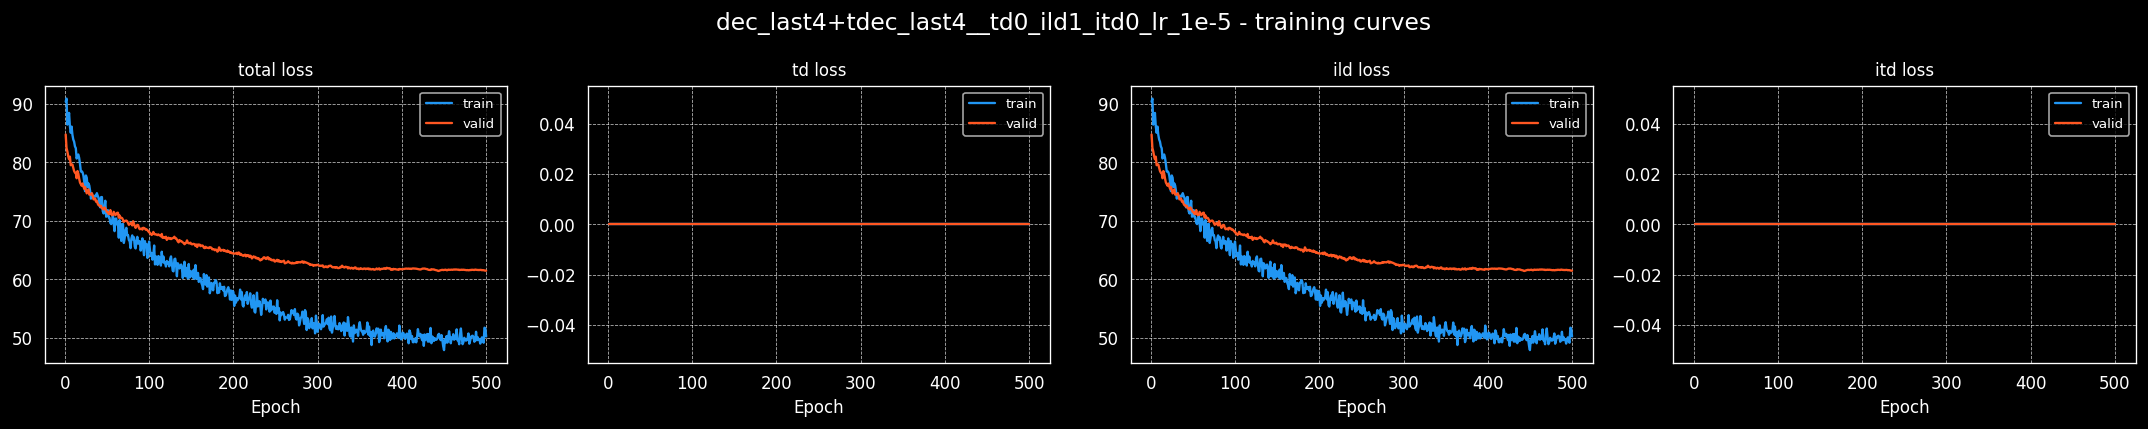

500 epochs, best valid loss = 61.4271 @ epoch 443 (td=0.0000, ild=61.4271, itd=0.0000)


In [7]:
history = pd.read_csv(RUN_DIR / "history.csv")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6), dpi=120)
for ax, key in zip(axes, ["total", "td", "ild", "itd"]):
    ax.plot(history["epoch"], history[f"train_{key}"], color="#2196F3", lw=1.4, label="train")
    ax.plot(history["epoch"], history[f"valid_{key}"], color="#FF5722", lw=1.4, label="valid")
    ax.set_title(f"{key} loss", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
plt.suptitle(f"{RUN} - training curves", fontsize=14)
plt.tight_layout()
plt.show()

best = history.loc[history["valid_total"].idxmin()]
print(f"{len(history)} epochs, best valid loss = {best['valid_total']:.4f} @ epoch {int(best['epoch'])} "
      f"(td={best['valid_td']:.4f}, ild={best['valid_ild']:.4f}, itd={best['valid_itd']:.4f})")

## Evaluation helpers

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking), then scored per source against the ground-truth stem:

- **SI-SDR** (dB) - separation quality.
- **Per-sub-band ILD MAE** (dB) - residual interaural **level**-difference error,
  averaged over time.

$$ \text{SI-SDR}(\hat{s}^{(s)}, s_{gt}^{(s)}) = 10 \cdot \log_{10} \left( \frac{\left\| \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} {\left\| \hat{s}^{(s)} - \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} \right) \quad \text{[dB]}$$
$$\mathcal{L}_{\text{ILD}}(k) = \frac{1}{T_f}\sum_{t=1}^{T}\big|\overline{\mathrm{ILD}}(k,t) - \mathrm{ILD}_{gt}(k,t)\big|$$

In [8]:
def separate(net: torch.nn.Module, wav: torch.Tensor) -> torch.Tensor:
    """Run an HTDemucs model on a full (2, T) mix. Returns (S, 2, T)."""
    net.eval()
    return apply_model(net, wav.unsqueeze(0), shifts=SHIFTS,
                       progress=False).squeeze(0)

def evaluate_on_tracks(net, tracks, tag, out_dir: Optional[Path] = None) -> dict:
    """Separate every test track with `net` and collect per-source metrics."""
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP - no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_audio(mix_path, SAMPLE_RATE).to(DEVICE)
        stems = separate(net, wav).cpu()   # (S, 2, T)

        if out_dir is not None:
            track_out_dir = out_dir / track_dir.name
            track_out_dir.mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(SOURCES):
                torchaudio.save(str(track_out_dir / f"{src}.wav"), stems[i], SAMPLE_RATE)

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_audio(tgt_path, SAMPLE_RATE)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]

            track_res[src] = dict(
                si_sdr=si_sdr(est, tgt),
                ild_bands_mae=ild_bands_mae(
                    est, tgt, n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"],
                    n_bands=EVAL["n_bands"], scale=EVAL["scale"], sample_rate=SAMPLE_RATE,
                ),
            )
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")

    print(f"{tag}: evaluation complete - {len(res)} tracks.\n")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
if LIMIT_TRACKS:
    tracks = tracks[:LIMIT_TRACKS]
print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


## Separate the test set - baseline and fine-tune

The frozen pre-trained HTDemucs baseline and the fine-tune are run on the **same**
test tracks.  The checkpoint is loaded into a fresh HTDemucs - the freeze strategy
is irrelevant at inference time, the `model_state` already holds all weights.
Each model is released before the next one, so peak memory is that of a single
model.

The baseline metrics are **cached** under `RUNS_ROOT/baseline_metrics.json`:
the frozen backbone gives the same numbers every session, so from the second
run on only the fine-tune is separated. The cache carries the band layout,
the dataset and the track list it was built with, and recomputes itself whenever
any of those changes (or when `USE_BASELINE_CACHE = False`).

In [9]:
def load_htdemucs(ckpt_path: Optional[Path] = None) -> torch.nn.Module:
    """Fresh HTDemucs; load a fine-tuned `model_state` when `ckpt_path` is given."""
    bag = get_model("htdemucs")
    net = bag.models[0] if hasattr(bag, "models") else bag
    net = net.to(DEVICE)
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        net.load_state_dict(ckpt["model_state"])
        print(f"Loaded {ckpt_path.name}: best epoch {ckpt.get('epoch', '?')}, "
              f"valid loss {ckpt.get('valid_loss', float('nan')):.4f}")
    return net.eval()

results_by_model = {}   # label -> {track: {src: {si_sdr, ild_bands_mae}}}

# -- Baseline: frozen pre-trained HTDemucs -------------------------------------
BASELINE_CACHE_PATH = RUNS_ROOT / "baseline_metrics.json"
_BAND_KEYS = ("ild_bands_mae", "itd_bands_mae")

def _baseline_fingerprint() -> dict:
    return {"eval": EVAL, "dataset_root": str(DATASET_ROOT),
            "tracks": [t.name for t in tracks],
            "compute_itd": False, "shifts": int(SHIFTS)}

def load_baseline_cache() -> Optional[dict]:
    """Cached baseline metrics, or None when absent, disabled or stale."""
    if not (USE_BASELINE_CACHE and BASELINE_CACHE_PATH.exists()):
        return None
    blob = json.loads(BASELINE_CACHE_PATH.read_text(encoding="utf-8"))
    if blob.get("fingerprint") != _baseline_fingerprint():
        print("Baseline cache is stale (band config, dataset or track list changed) "
              "- recomputing it.")
        return None
    # Per-band curves are stored as plain lists; bring them back as arrays.
    return {
        track: {src: {**m, **{k: np.asarray(m[k]) for k in _BAND_KEYS if k in m}}
                for src, m in track_res.items()}
        for track, track_res in blob["results"].items()
    }

def save_baseline_cache(res: dict) -> None:
    BASELINE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    BASELINE_CACHE_PATH.write_text(json.dumps({
        "fingerprint": _baseline_fingerprint(),
        "results": {
            track: {src: {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                          for k, v in m.items()}
                    for src, m in track_res.items()}
            for track, track_res in res.items()
        },
    }), encoding="utf-8")
    print(f"Baseline metrics cached to {BASELINE_CACHE_PATH}\n")

_cached = load_baseline_cache()
if _cached is not None:
    results_by_model[BASELINE_LABEL] = _cached
    print(f"{BASELINE_LABEL}: reusing cached metrics for {len(_cached)} tracks "
          f"({BASELINE_CACHE_PATH.name}) - set USE_BASELINE_CACHE = False to redo it.\n")
else:
    net = load_htdemucs(None)
    results_by_model[BASELINE_LABEL] = evaluate_on_tracks(net, tracks, tag=BASELINE_LABEL)
    save_baseline_cache(results_by_model[BASELINE_LABEL])
    del net
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# -- Fine-tune -----------------------------------------------------------------
net = load_htdemucs(CKPT)
out_dir = (RUN_DIR / "estimates") if SAVE_ESTIMATES else None
results_by_model[RUN] = evaluate_on_tracks(net, tracks, tag=RUN, out_dir=out_dir)
if out_dir is not None:
    print(f"Estimates saved under {out_dir}")
del net
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

htdemucs (baseline): reusing cached metrics for 50 tracks (baseline_metrics.json) - set USE_BASELINE_CACHE = False to redo it.

Loaded htdmcs_sp_dec_last4+tdec_last4.pt: best epoch 443, valid loss 61.4271
Running dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5 on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (15.3s)
[2/50] AM Contra - Heart Peripheral ... done (9.2s)
[3/50] Angels In Amplifiers - I'm Alright ... done (8.1s)
[4/50] Arise - Run Run Run ... done (9.7s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (12.8s)
[6/50] BKS - Bulldozer ... done (16.3s)
[7/50] BKS - Too Much ... done (9.9s)
[8/50] Bobby Nobody - Stitch Up ... done (9.8s)
[9/50] Buitraker - Revo X ... done (12.1s)
[10/50] Carlos Gonzalez - A Place For Us ... done (11.0s)
[11/50] Cristina Vane - So Easy ... done (11.3s)
[12/50] Detsky Sad - Walkie Talkie ... done (8.5s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (8.4s)
[14/50] Forkupines - Semantics ... done (12.0s)
[15/50] G

## Summary - SI-SDR and ILD MAE per source

Per-source metrics averaged over all test tracks, for the baseline and the
fine-tune:

- SI-SDR in dB (higher is better)
- the scalar ILD MAE in dB (mean over the sub-bands, lower is better).

The `All` row averages the four sources, and the `delta` columns are fine-tune
minus baseline. A good fine-tune has a negative `dILD MAE` at a `dSI-SDR` close
to zero.

In [10]:
def aggregate(res):
    ag = {src: {"si_sdr": [], "ild_bands_mae": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["si_sdr"].append(m["si_sdr"])
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
    return ag

def per_source_table(ag) -> pd.DataFrame:
    """Means over tracks, per source (+ `All` row): SI-SDR and scalar ILD MAE."""
    df = pd.DataFrame({
        "SI-SDR (dB)":  {s: float(np.mean(ag[s]["si_sdr"]))                    for s in SOURCES},
        "ILD MAE (dB)": {s: float(np.mean(np.mean(ag[s]["ild_bands_mae"], 0))) for s in SOURCES},
    }).reindex(SOURCES)
    df.loc["All"] = df.mean(axis=0)
    return df

agg_by_model = {label: aggregate(res) for label, res in results_by_model.items()}

base_table = per_source_table(agg_by_model[BASELINE_LABEL])
run_table  = per_source_table(agg_by_model[RUN])

summary = pd.concat({BASELINE_LABEL: base_table, RUN: run_table}, axis=1)
summary[("delta", "dSI-SDR (dB)")]  = run_table["SI-SDR (dB)"]  - base_table["SI-SDR (dB)"]
summary[("delta", "dILD MAE (dB)")] = run_table["ILD MAE (dB)"] - base_table["ILD MAE (dB)"]

print(f"{RUN} vs {BASELINE_LABEL} - {len(tracks)} test tracks\n")
with pd.option_context("display.float_format", lambda x: f"{x:+.3f}", "display.width", 200):
    print(summary)
summary

dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5 vs htdemucs (baseline) - 50 test tracks

       htdemucs (baseline)              dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5                     delta              
               SI-SDR (dB) ILD MAE (dB)                                 SI-SDR (dB) ILD MAE (dB) dSI-SDR (dB) dILD MAE (dB)
drums               +9.778       +6.473                                      +5.903       +5.560       -3.876        -0.913
bass                +7.656       +6.578                                      +3.568       +3.864       -4.088        -2.713
other               +4.293       +6.292                                      -0.828       +5.938       -5.121        -0.354
vocals              +7.884       +5.954                                      +6.398       +5.728       -1.485        -0.226
All                 +7.403       +6.324                                      +3.760       +5.273       -3.642        -1.052


htdemucs (baseline)               \
               SI-SDR (dB) ILD MAE (dB)   
drums             9.778259     6.473217   
bass              7.655935     6.577535   
other             4.293331     6.292466   
vocals            7.883565     5.953654   
All               7.402773     6.324218   

       dec_last4+tdec_last4__td0_ild1_itd0_lr_1e-5                     delta  \
                                       SI-SDR (dB) ILD MAE (dB) dSI-SDR (dB)   
drums                                     5.902704     5.559852    -3.875556   
bass                                      3.568409     3.864276    -4.087527   
other                                    -0.827858     5.938440    -5.121189   
vocals                                    6.398246     5.727877    -1.485319   
All                                       3.760375     5.272611    -3.642398   

                      
       dILD MAE (dB)  
drums      -0.913365  
bass       -2.713259  
other      -0.354026  
vocals     -0.225777  
All        -1.051607

## Per-band ILD MAE - fine-tune vs baseline

One panel per source; each curve is a model's mean per-band ILD MAE over the test
set, i.e. for band $k$ and source $s$:

$$  \mathcal{L}_{\text{ILD}}(k)^{(s)} = \frac{1}{N} \sum_{n=1}^{N} \mathcal{L}_{\text{ILD}_{n}}(k)^{(s)}\quad\text{[dB]}$$

The fine-tune preserves the level cue better than the baseline where its curve
sits **below** the baseline curve.

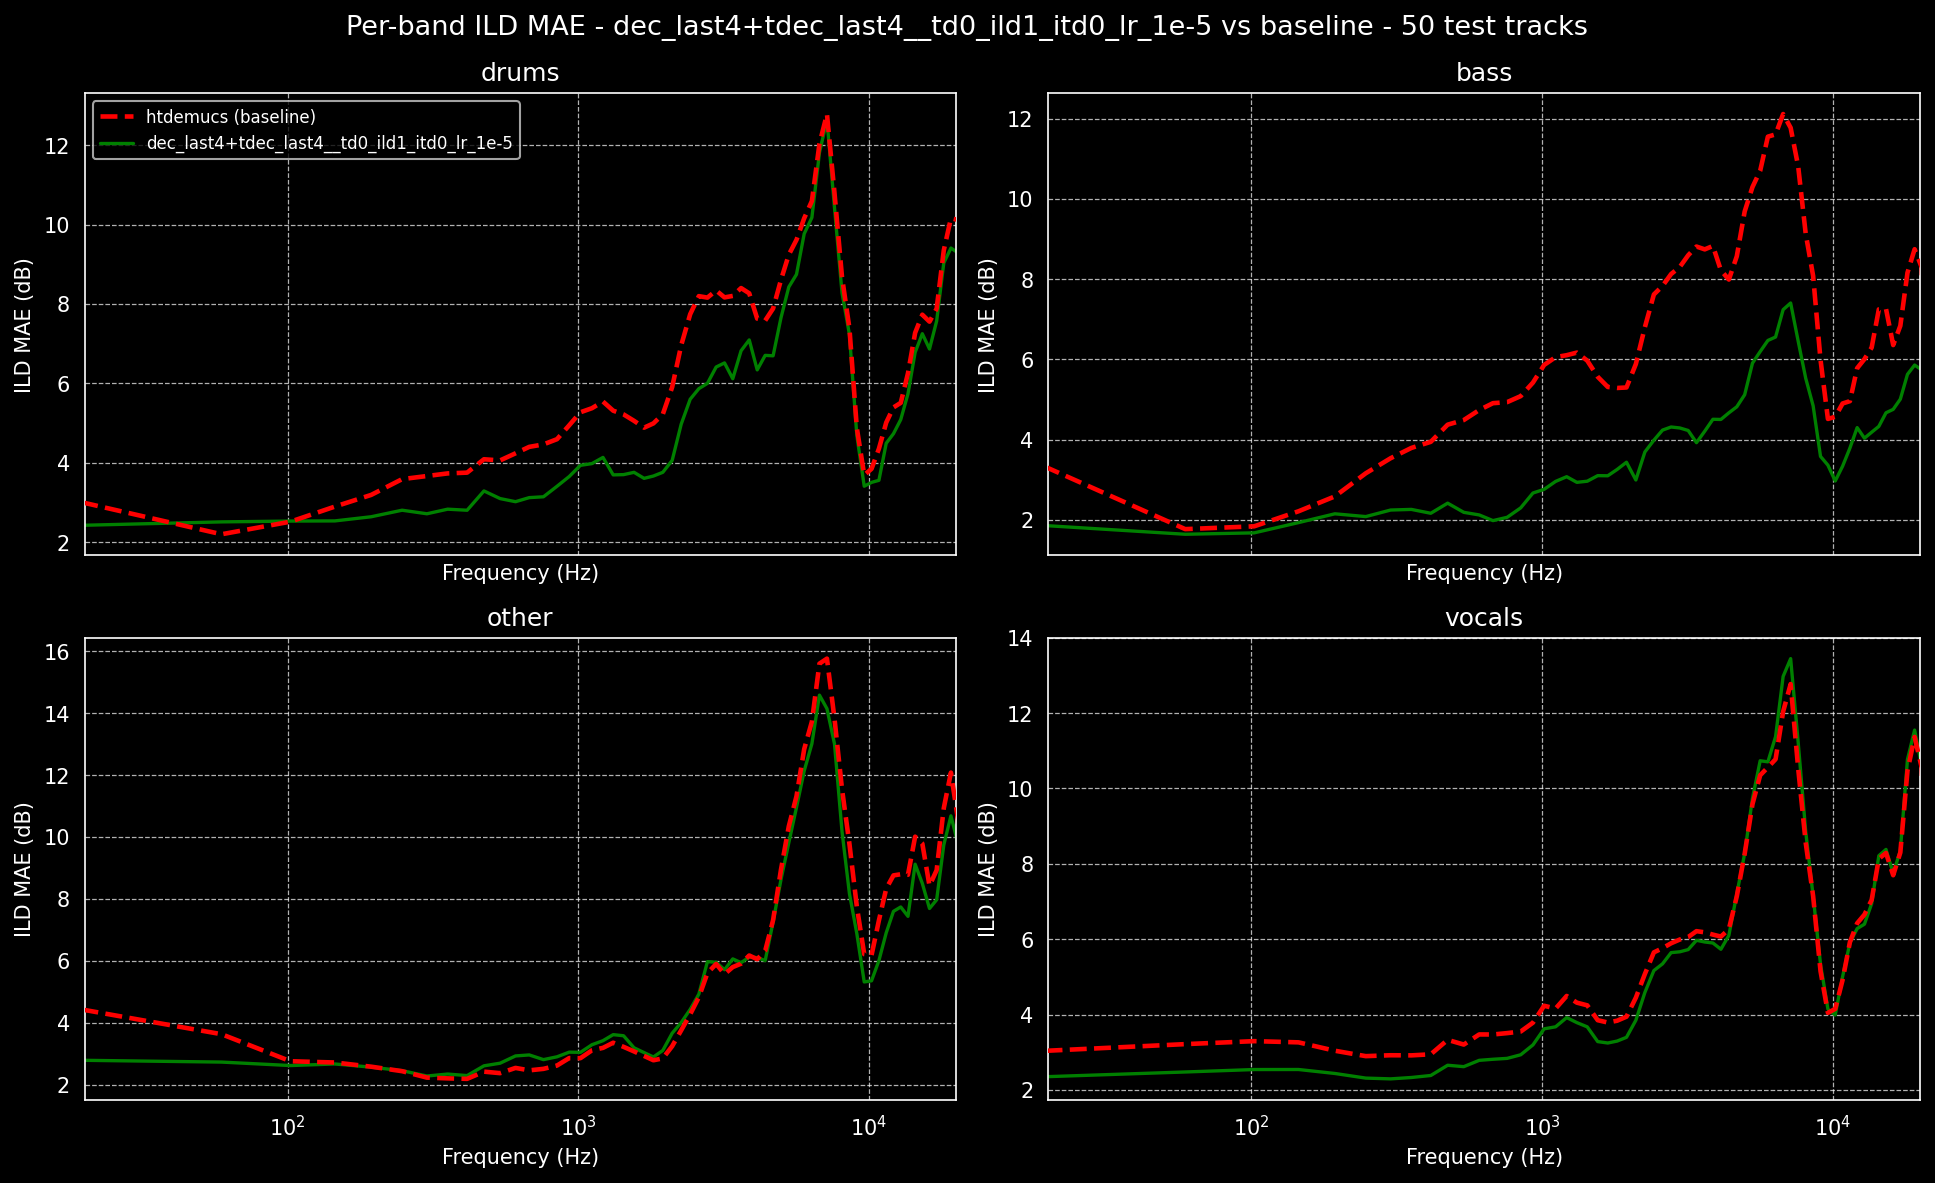

In [11]:
# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
n_bands = EVAL["n_bands"]
if EVAL["scale"] == "mel":
    _ba     = mel_bin_assignment(int(EVAL["n_fft"]), n_bands, int(SAMPLE_RATE))
    _bin_hz = np.arange(int(EVAL["n_fft"]) // 2 + 1) * (int(SAMPLE_RATE) / int(EVAL["n_fft"]))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

def mean_bands(ag, src, key):
    return np.mean(ag[src][key], axis=0)   # (n_bands,)

_STYLES = {
    BASELINE_LABEL: dict(color="red",   lw=2.2, ls="--", zorder=3),
    RUN:            dict(color="green", lw=1.6, ls="-"),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150, sharex=True)
for ax, src in zip(axes.ravel(), SOURCES):
    for label, style in _STYLES.items():
        ag = agg_by_model[label]
        if not ag[src]["ild_bands_mae"]:
            continue
        ax.plot(band_hz, mean_bands(ag, src, "ild_bands_mae"), label=label, **style)
    ax.set_xscale("log")
    ax.set_xlim(20, 20000)
    ax.set_title(src)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("ILD MAE (dB)")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
axes.ravel()[0].legend(fontsize=8, loc="best")
fig.suptitle(f"Per-band ILD MAE - {RUN} vs baseline - {len(tracks)} test tracks", fontsize=13)
plt.tight_layout()
plt.show()